# H&M Customer Segmentation Using RFM and K-Means

## 1. Load and Validate the Customer-Level Dataset
RFM features were calculated from the historical observation window, which ended 120 days before the dataset’s final date. The final 120 days were reserved as the future outcome window.

The `repurchase` outcome is retained for post-clustering evaluation only and is not included in the K-Means feature set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("/Volumes/USB/H&M Data/RFM_repurchasein120days.csv")
df.head()

,customer_id,recency,frequency,log_frequency,monetary,log_monetary,repurchase
0,00007d2de826758b65a93dd24ce629ed66842531df6699...,12,5,1.791759,2.086356,1.126991,0
1,0001420326c217a367048472e05395373c40a039f6fd45...,110,1,0.693147,0.091475,0.087530,0
2,000abc5e9575b453ff1cde1e5d644f1c671daef57e0f85...,130,1,0.693147,0.123661,0.116592,1
3,001719ed7b00964ac3206968c087f15d261d3289b89b0f...,15,2,1.098612,0.132136,0.124106,1
4,0019766e0e39e6eca054a9be24fd3492680abcc4ee674b...,59,19,2.995732,1.575966,0.946225,1


In [4]:
print(df.shape)
print(df["customer_id"].nunique())

(985967, 7)
985967


In [5]:
print(df.isna().sum())

customer_id      0
recency          0
frequency        0
log_frequency    0
monetary         0
log_monetary     0
repurchase       0
dtype: int64


In [6]:
print(df.describe())

             recency      frequency  log_frequency       monetary  \
count  985967.000000  985967.000000  985967.000000  985967.000000   
mean      122.202333       4.416306       1.399303       0.434635   
std       103.722638       5.356519       0.703523       0.694311   
min         0.000000       1.000000       0.693147       0.000508   
25%        33.000000       1.000000       0.693147       0.083000   
50%        94.000000       2.000000       1.098612       0.203339   
75%       190.000000       6.000000       1.945910       0.497983   
max       364.000000     205.000000       5.327876      29.793169   

        log_monetary     repurchase  
count  985967.000000  985967.000000  
mean        0.297777       0.494801  
std         0.315331       0.499973  
min         0.000508       0.000000  
25%         0.079735       0.000000  
50%         0.185100       0.000000  
75%         0.404120       1.000000  
max         3.427293       1.000000  


## 2. Prepare and Standardize RFM Features

In [7]:
feature_columns = ["recency","log_frequency","log_monetary"]
rfm_features = df[feature_columns].copy()

In [8]:
scaler = StandardScaler()

In [9]:
rfm_scaled = scaler.fit_transform(rfm_features)

In [10]:
scaled_summary = pd.DataFrame(rfm_scaled,columns=feature_columns).agg(["mean", "std"])
scaled_summary

,recency,log_frequency,log_monetary
mean,4.018376e-17,3.912296e-16,-4.958111e-18
std,1.000001e+00,1.000001e+00,1.000001e+00


## 3. Select the Number of Clusters Using the Elbow Method

In [11]:
sample_size = min(100_000, len(df))

In [12]:
rng = np.random.default_rng(42)

In [13]:
sample_indices = rng.choice(len(rfm_scaled),size=sample_size,replace=False)

In [14]:
rfm_elbow_sample = rfm_scaled[sample_indices]

In [15]:
k_values = range(2, 11)
inertia_values = []

In [16]:
for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(rfm_elbow_sample)
    inertia_values.append(model.inertia_)
    print(k, model.inertia_)

2 155351.0044206841
3 99632.11463104002
4 72940.73448156101
5 61987.03136703344
6 52472.50180398853
7 45657.542199620584
8 41131.34257024941
9 38029.920537866055
10 35373.73190753741


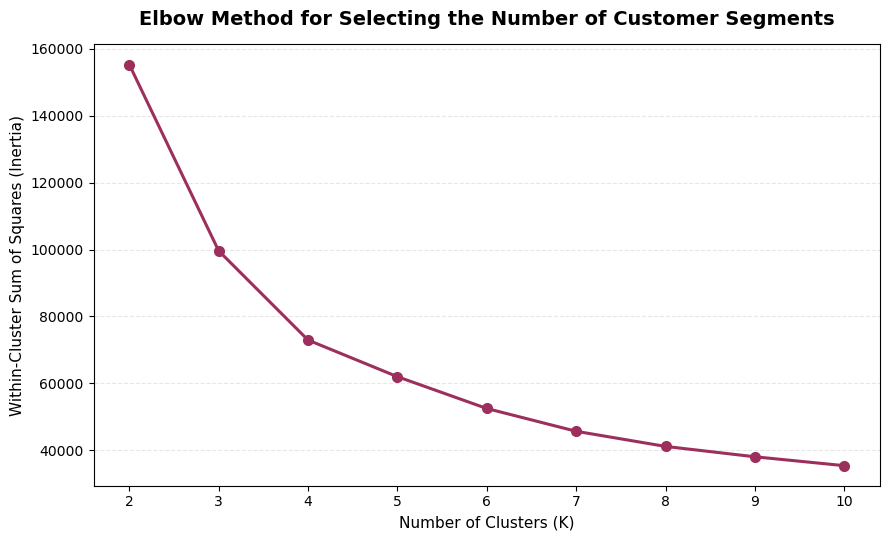

In [17]:
plt.figure(figsize=(9, 5.5))
plt.plot(
    list(k_values),
    inertia_values,
    marker="o",
    linewidth=2.2,
    markersize=7,
    color="#9C2F5C"
)
plt.title(
    "Elbow Method for Selecting the Number of Customer Segments",
    fontsize=14,
    fontweight="bold",
    pad=14
)
plt.xlabel("Number of Clusters (K)", fontsize=11)
plt.ylabel("Within-Cluster Sum of Squares (Inertia)", fontsize=11)
plt.xticks(list(k_values))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("/Volumes/USB/H&M Data/kmeans_elbow_method.png",dpi=300,bbox_inches="tight")
plt.show()

In [18]:
elbow_results = pd.DataFrame({"k": list(k_values),"inertia": inertia_values})
elbow_results["inertia_reduction_pct"] = (-elbow_results["inertia"].pct_change() * 100)
elbow_results

,k,inertia,inertia_reduction_pct
0,2,155351.004421,NaN
1,3,99632.114631,35.866450
2,4,72940.734482,26.789936
3,5,61987.031367,15.017265
4,6,52472.501804,15.349226
5,7,45657.542200,12.987678
6,8,41131.342570,9.913367
7,9,38029.920538,7.540289
8,10,35373.731908,6.984471


### Cluster Selection
The elbow curve shows substantial reductions in inertia from K=2 to K=4, followed by smaller incremental improvements. K=4 was selected as a balance between cluster compactness and business interpretability.

## 4. Fit the Final K-Means Model

In [19]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=20)
df["cluster"] = kmeans.fit_predict(rfm_scaled)

## 5. Profile and Name the Customer Segments

In [20]:
cluster_profile = (df.groupby("cluster").agg(
          customer_count=("customer_id", "count"),
          average_recency=("recency", "mean"),
          average_frequency=("frequency", "mean"),
          average_monetary=("monetary", "mean"),
          future_purchase_rate=("repurchase", "mean")
      ).reset_index())
cluster_profile["customer_share"] = (cluster_profile["customer_count"] / len(df))
cluster_profile

,cluster,customer_count,average_recency,average_frequency,average_monetary,future_purchase_rate,customer_share
0,0,282660,261.333556,1.562135,0.140577,0.248443,0.286683
1,1,279695,65.876984,6.585995,0.539194,0.740342,0.283676
2,2,328787,75.999386,1.806781,0.143418,0.379106,0.333467
3,3,94825,33.808089,15.572507,2.012509,0.906059,0.096175


The `future_purchase_rate` represents the proportion of customers in each cluster who made at least one purchase during the subsequent 120-day outcome window.

Future purchase behaviour was not used to create the clusters. It was introduced only after clustering to evaluate whether the historical RFM segments distinguish subsequent purchase behaviour.

In [21]:
df1 = df.copy()

In [22]:
cluster_names = {
    0: "Lapsed Low-Engagement",
    1: "Developing Repeat",
    2: "Recent Occasional",
    3: "Loyal / Highly Engaged"
}
df1["segment"] = df1["cluster"].map(cluster_names)

In [23]:
cluster_profile_named = (df1.groupby(["cluster", "segment"]).agg(
          customer_count=("customer_id", "count"),
          average_recency=("recency", "mean"),
          average_frequency=("frequency", "mean"),
          average_monetary=("monetary", "mean"),
          future_purchase_rate=("repurchase", "mean")
      ).reset_index())
cluster_profile_named["customer_share"] = (cluster_profile_named["customer_count"] / len(df1))
cluster_profile_named

,cluster,segment,customer_count,average_recency,average_frequency,average_monetary,future_purchase_rate,customer_share
0,0,Lapsed Low-Engagement,282660,261.333556,1.562135,0.140577,0.248443,0.286683
1,1,Developing Repeat,279695,65.876984,6.585995,0.539194,0.740342,0.283676
2,2,Recent Occasional,328787,75.999386,1.806781,0.143418,0.379106,0.333467
3,3,Loyal / Highly Engaged,94825,33.808089,15.572507,2.012509,0.906059,0.096175


## 6. Export Datasets

In [24]:
df.to_csv("/Volumes/USB/H&M Data/hm_customer_segments.csv",index=False)

In [25]:
df1.to_csv("/Volumes/USB/H&M Data/hm_customer_segments_named.csv",index=False)

In [26]:
cluster_profile.to_csv("/Volumes/USB/H&M Data/hm_cluster_profile.csv",index=False)

In [27]:
cluster_profile_named.to_csv("/Volumes/USB/H&M Data/hm_cluster_profile_named.csv",index=False)